In [33]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

In [35]:
iris = load_iris()
X = iris.data#提取4个特征 为Numpy数组

In [37]:
print(iris.feature_names) #提取特征名称

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [39]:
y = iris.target #提取鸢尾花数据集标签列(自带),Numpy数组 这里提取出来的是000...,111...,222...
print(np.unique(y)) #返回不重复的特殊标签0,1,2

[0 1 2]


In [41]:
print(iris.target_names)#提取分类标签 三个数据

['setosa' 'versicolor' 'virginica']


In [43]:
X_df = pd.DataFrame(X,columns = ['X1','X2','X3','X4']) #创建pdDF数据帧
X_df.head()

,X1,X2,X3,X4
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
X_df.tail()

,X1,X2,X3,X4
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [21]:
round(X_df.describe(),2) #汇总计算数据

,X1,X2,X3,X4
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [29]:
X,y = load_iris(as_frame = True,return_X_y = True) #X为Dataframe格式y为PandasSeries
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [31]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [68]:
import matplotlib.pyplot as plt
import numpy as np
#预处理模块中的一个预处理类,对数据进行标准化处理
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles,make_moons
#导入聚类用的简单数据 生成分类用的复杂数据
from sklearn.datasets import make_blobs,make_classification

In [70]:
n_samples = 500

In [72]:
#测试机器学习算法
circles = make_circles(n_samples = n_samples,
                       factor = 0.5,noise = 0.1) #比例因子 高斯噪声的标准差

In [74]:
#测试非线性数据算法
moons = make_moons(n_samples = n_samples,
                   noise = 0.1) 

In [76]:
blobs = make_blobs(n_samples = n_samples,
                   centers = 4,#数据质心位置 高斯分布质心位置
                   cluster_std = 1.5)#每一个聚类的标准差

In [78]:
transformation = [[0.4,0.2],[-0.4,1.2]]
X = np.dot(blobs[0],transformation)
rotated = (X,blobs[1])

In [82]:
varied = make_blobs(n_samples = n_samples,
                    cluster_std=[1.0,2.5,0.5]) #每个高斯分布指定不同标准差

In [86]:
#虚拟飞雷数据集
classif = make_classification(n_samples = n_samples,
                              n_features = 2, 
                              n_redundant = 0,
                              n_informative = 2,
                              n_clusters_per_class = 1)

In [88]:
datasets = [circles,moons, blobs, rotated,varied,classif]

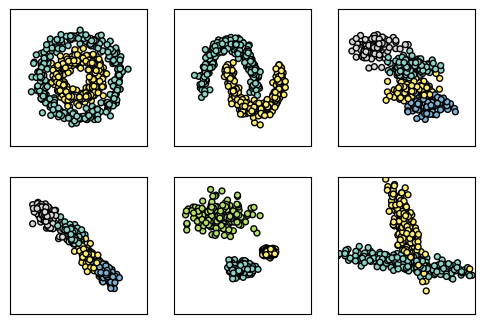

In [102]:
#有标签可视化
fig,axes = plt.subplots(2,3,figsize = (6,4))
axes = axes.flatten()

for dataset_idx,ax_idx in zip(datasets,axes):
    #y是标签数组,每一个点对应一个标签
    #在make_...中自动生成的 用于分类上色   生成时候生成的两个numpy组合元组
    X,y = dataset_idx
    #特征缩放
    X = StandardScaler().fit_transform(X)
    ax_idx.scatter(X[:,0],X[:,1],s = 18,
                    c = y,cmap='Set3',
                    edgecolors = 'k')
    ax_idx.set_xlim(-3,3)
    ax_idx.set_ylim(-3,3)
    #必须传入可迭代对象,列表元组等,但是可以是空的.不碍事清空刻度线
    ax_idx.set_xticks(())
    ax_idx.set_yticks(())
    ax_idx.set_aspect('equal',adjustable = 'box')

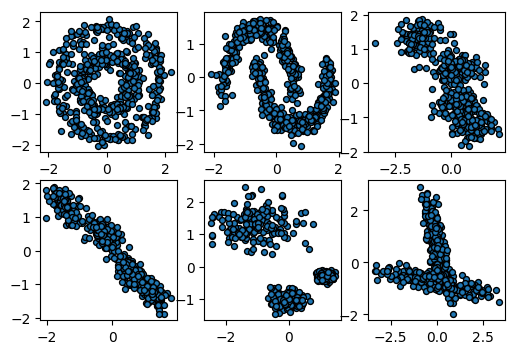

In [108]:
#无标签可视化
fig,axes = plt.subplots(2,3,figsize = (6,4))
axes = axes.flatten()

for dataset_idx,ax_idx in zip(datasets,axes):
    X,y = dataset_idx
    X = StandardScaler().fit_transform(X)
    #每一列表示一个特征,0列为x坐标 1列为y坐标.每一行为一个点
    ax_idx.scatter(X[:,0],X[:,1],s = 18,edgecolors = 'k')

In [110]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [112]:
iris = load_iris()
X = iris.data
y = iris.target

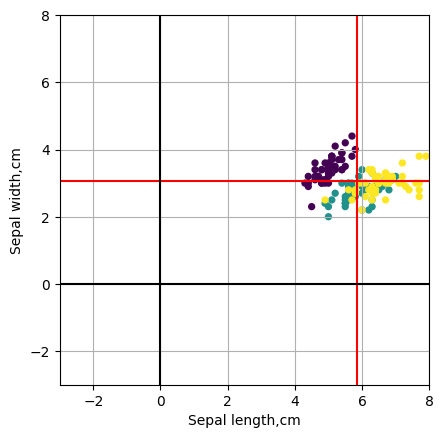

In [136]:
fig,ax = plt.subplots()
#原始数据散点图 s表示size
#前两个参数表示x y的位置
ax.scatter(X[:,0],X[:,1],s = 18,c = y)
#质心位置  均值水平竖直两条线交点为质心
#注意函数vh的不同用于xy的方向
ax.axvline(x = X[:,0].mean(),c = 'r')
ax.axhline(y = X[:,1].mean(),c = 'r')
ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.set_xlabel('Sepal length,cm')
ax.set_ylabel('Sepal width,cm')
ax.grid(True)
ax.set_aspect('equal',adjustable = 'box')
#硬性设置边界,不触发自适应变化,更死板  xlim更智能灵活(效果可能一样)
ax.set_xbound(lower = -3,upper = 8)
ax.set_ybound(lower = -3,upper = 8)

In [142]:
from sklearn.preprocessing import StandardScaler #导入标准化函数
scaler = StandardScaler() #建立标准化函数实例 只要调用,会存储数据的初始均值和标准差.方便反复使用
X_z_score = scaler.fit_transform(X) #使用StandardScaler实例 学习+标准化 是存储变化后的数据(新的均值标准差等)

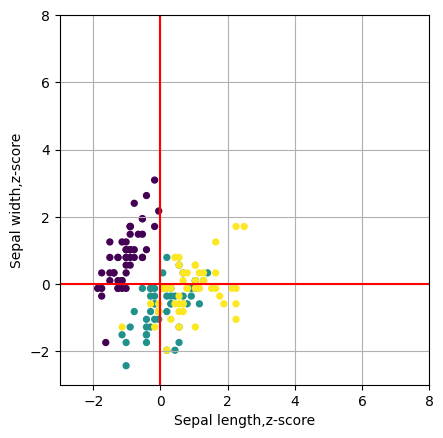

In [158]:
fig,ax = plt.subplots()
ax.scatter(X_z_score[:,0],X_z_score[:,1],s = 18,c = y)
ax.axvline(x = X_z_score[:,0].mean(),c = 'r')
ax.axhline(y = X_z_score[:,1].mean(),c = 'r')
ax.set_xlabel('Sepal length,z-score')
ax.set_ylabel('Sepal width,z-score')
ax.grid(True)
ax.set_aspect('equal',adjustable = 'box')
ax.set_xbound(-3,8)
ax.set_ybound(-3,8)

In [162]:
from sklearn.datasets import load_iris
#k近邻插补 k表示近邻数量
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [166]:
#导入鸢尾花书数据, pd数组 y为数据标签(0/1/2)
X,y = load_iris(as_frame = True ,return_X_y = True)

In [180]:
#复制后数值类型不变, df支持使用numpy数组来索引
X_NaN = X.copy()
#形成0-1之间的连续均匀随机数numpy数组 形状与鸢尾花特征一致
#每个小数的概率均等 默认为float64精度,不规定几位
mask = np.random.uniform(0,1,size = X_NaN.shape)
#将小于0.4的标记True 其余为False
#结果为布尔型的numpy,形状不变
mask = (mask <= 0.4)
#True位置设置为缺失值NaN
#df知识numpy索引
X_NaN[mask] = np.NaN

In [182]:
iris_df_NaN = X_NaN.copy()
#仅仅操作了X y不会消失
#将y添加到新的列中
iris_df_NaN['species'] = y

In [190]:
#范围具体位置是否缺失,是为True否为False
is_NaN = iris_df_NaN.isna()
#isnull检查每个单元格时不时NaN sum将True为1计算有多少个1 除以总数
print(iris_df_NaN.isnull().sum()/len(iris_df_NaN))

#isna() isnull() 名称不同,功能相同

sepal length (cm)    0.406667
sepal width (cm)     0.460000
petal length (cm)    0.393333
petal width (cm)     0.426667
species              0.000000
dtype: float64


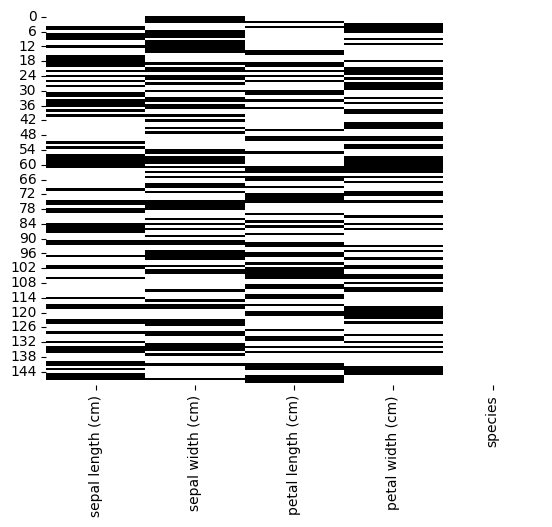

In [194]:
fig,ax = plt.subplots()
ax = sns.heatmap(is_NaN,
                 cmap = 'gray_r',
                 cbar = False)
#黑色代表缺失值

In [204]:
#开始插值

#建模参数为考虑的邻近样本量
knni = KNNImputer(n_neighbors = 5)
#应用到数据进行拟合fit和转换transform
#拟合为根据一致数据训练邻近模型
#转换为通过训练后的模型进行插补
#X_NaN为df 生成的X_NaN_kNN为numpy数组
X_NaN_kNN = knni.fit_transform(X_NaN)
#将值插入原数据 列名不变,索引不变 将numpy转换为df格式
iris_df_kNN = pd.DataFrame(X_NaN_kNN,columns = X_NaN.columns,
                           index = X_NaN.index)
iris_df_kNN['species'] = y

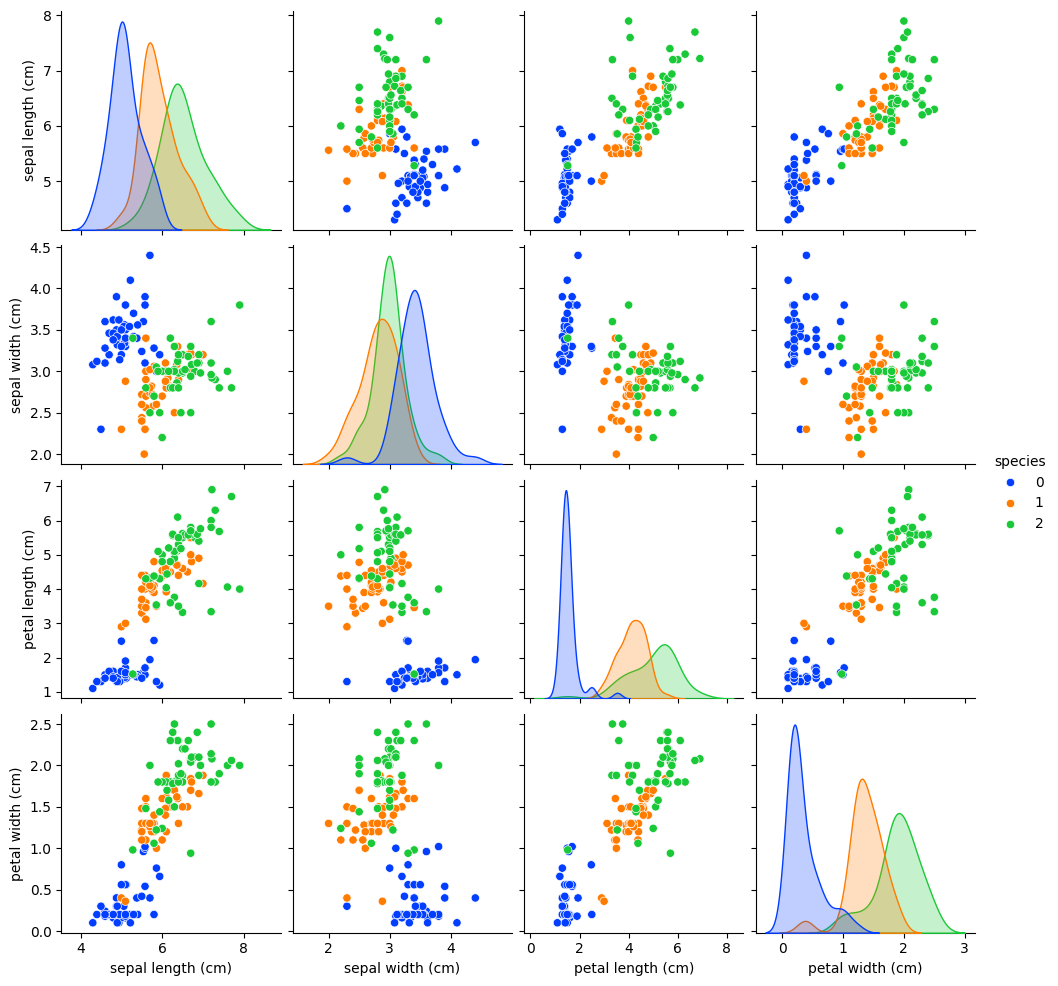

In [206]:
sns.pairplot(iris_df_kNN,hue='species',
            palette = 'bright')

In [212]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs,make_moons
from sklearn.svm import OneClassSVM #实线支持向量机
from sklearn.covariance import EllipticEnvelope #多元高斯分布配置椭圆,离椭圆很远的点为异常值
from sklearn.ensemble import IsolationForest #隔离森林方法

In [216]:
#生成数据
n_samples = 500
outliers_fraction = 0.10
n_outliers = int(outliers_fraction * n_samples)
#正常点数量
n_inliers = n_samples - n_outliers
#生成异常点,限制最小值和最大值,size中第一个参数为个数(行数)第二个表示有两个特征分别代表xy(范围生成都遵循最大值最小值)
X_outliers = np.random.uniform(low = -6,high = 6,
                               size = (n_outliers,2))

In [222]:
np.random.RandomState(0) #随机数生成器确保种子是0 这里的种子与下方种子无关 #?
#定义字典,参数1为控制种子  参2是控制生成样本数 参数3为设定每个数据点的特征为2(x,y) 
blobs_params = dict(random_state = 0,
                    n_samples = n_inliers,n_features=2)

{'random_state': 0, 'n_samples': 450, 'n_features': 2}

In [226]:
#构造4组数据集

#总体生成方式,以及为什么
datasets = [
    make_blobs(centers = [[0,0],[0,0]],  #是两簇重叠 中心坐标数量和标准差数量需要对应
                #标准差参数  **表示包含字典,将字典的参数直接传给函数
               #[0]表示取出返回值的索引为0的值'X'特征数据不要y标签  因为输出值为(X,y)
               cluster_std = 0.5,**blobs_params)[0], 
    make_blobs(centers = [[2,2],[-2,-2]],
               cluster_std = [0.5,0.5],**blobs_params)[0],
    make_blobs(centers = [[2,2],[-2,-2]],
               cluster_std = [1.5,0.3],**blobs_params)[0],
    #放大4倍,拉开间距
    #月牙形数据特征矩阵
    #最后表示整体向左下平移
    4.0*(make_moons(n_samples = n_samples,noise = 0.05,
                   random_state = 0)[0] - np.array([0.5,0.25]))]

In [237]:
#处理离群值
anomaly_algorithms = [
    #椭圆包络的异常值检测模型  参数1指定异常值比例,0-0.5之间
    EllipticEnvelope(contamination = outliers_fraction,
                     random_state = 42),
    #向量机异常检测模型 参数1为异常值比例 0-1之间 参数2指定核函数类型 参数3控制影响范围
    OneClassSVM(nu=outliers_fraction,kernel = 'rbf',
                gamma = 0.1),
    #隔离森林检测模型
    IsolationForest(contamination = outliers_fraction,
                    random_state = 42)]

In [243]:
#网格化数据绘制等高线
xx,yy = np.meshgrid(np.linspace(-7,7,150),
                    np.linspace(-7,7,150))
#使用快捷连接器,拼成二维数组(x,y)样式的点
#里面的ravel展开成150*150个x坐标点x值,y同理
xy = np.c_[xx.ravel(),yy.ravel()]
#不会因为array()的括号增加嵌套,继续保持一维字符串
#16进制字母大小写保持一致
colors = np.array(['#377eb8','#ff7f00'])

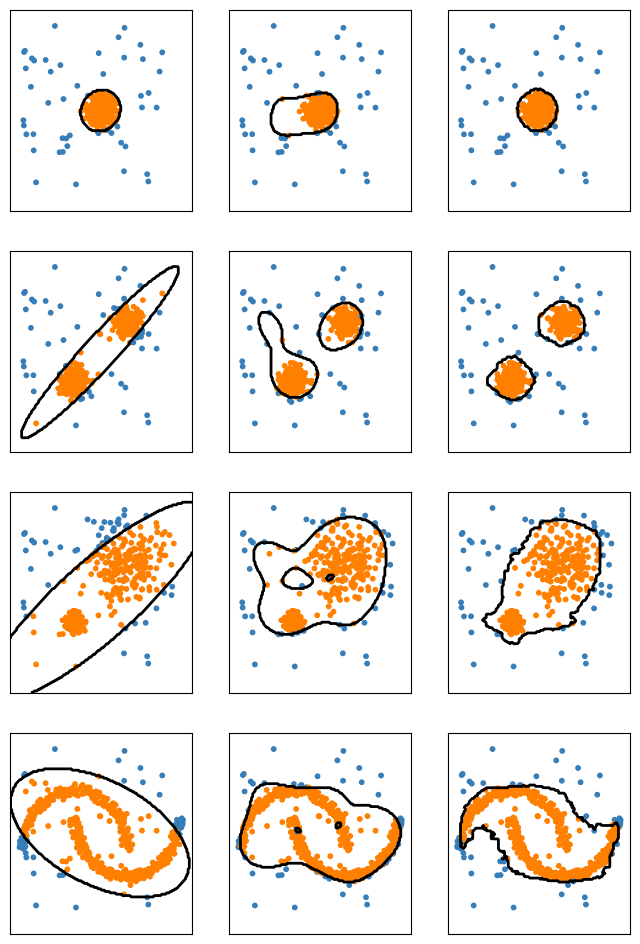

In [272]:
#可视化
fig = plt.figure(figsize = (8,12))
plot_idx = 1
for idx,X in enumerate(datasets): #enumerate输出序号给idx(在前) X为正常坐标点 (在后)
    X = np.concatenate([X,X_outliers],axis = 0) #将两个按行合并堆叠在一起(列数不变

    for algorithm in anomaly_algorithms:
        y_pred = algorithm.fit(X).predict(X) #建模,训练,预测出离群值

        ax = fig.add_subplot(4,3,plot_idx);plot_idx += 1
        Z = algorithm.predict(xy) #检测每个点预测是不是离群值,使用之前训练(fit)的模型 结果为1或者-1
        Z = Z.reshape(xx.shape)

        ax.contour(xx,yy,Z,levels = [0],linewidths = 2,colors = 'black') #这里[0]表示接近0的地方是边界,Z的值仅有1或者-1在大概的边界绘制
        ax.scatter(X[:,0],X[:,1],s=10,color = colors[(y_pred +1)//2]) #y_pred是-1或1 公式的意思是-1换成0 1保持   //为整数除法
        ax.set_xlim(-7,7);ax.set_ylim(-7,7)
        ax.set_xticks(());ax.set_yticks(())